![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_2/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Segmentación de Clientes con Clustering Jerárquico y DBSCAN

El objetivo de este caso-taller es analizar una base de datos ficticia sobre clientes de una tienda y buscar encontrar grupos de clientes que permitan generar estrategias de marketing focalizadas. La base se encuentra en los `Archivos de Laboratorio` en la carpeta `data` y cuenta con 200 observaciones y 5 variables:

- `Id_Cliente`: identificador de cliente.
- `Genero`: género del cliente: Mujer, Hombre
- `Edad`: edad en años
- `Ingreso`: ingresos anuales
- `Puntaje_Gasto`: es una variable que mide cuán a menudo un cliente compra en la tienda, siendo 100 el puntaje más alto.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

En la carpeta `data` se encuentra el archivo `datos_clientes.csv` cargue estos datos en su *cuaderno*.

In [43]:
# Utilice este espacio para escribir el código.

# Utilice este espacio para escribir el código.

#### Función para instalar las librerías usadas en la primera parte del Taller 1 (en caso de que no las tenga instaladas)
import sys
import subprocess

def install_load(package):
    try:
        __import__(package)
        print(f'La librería {package} ya está instalada')
    except ImportError:
        print(f'La librería {package} no se encontró. Instalando la librería {package}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f'La librería {package} ha sido instalada')    

### Lista con el nombre de las librerías usadas en el ejercicio
librerias_taller = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'scipy']

### Loop-for para las librerías
for i in librerias_taller:
    install_load(i)


#### Librerías usadas en la primera parte del Taller 1
import numpy as np                        ##  Computación científica en Python
import pandas as pd                       ##  Manejo y manipulación de datos en Python
import matplotlib.pyplot as plt           ##  Gráficos básicos en Python
import seaborn as sns                     ##  Gráficos estadísticos en Python
import scipy.cluster.hierarchy as sch     ## Método de Ward con distancia euclidiana y gráfico del dendograma


from scipy import stats                               ## Medidas de tendencia central
from sklearn.preprocessing import StandardScaler      ## Estandarización de variables
from sklearn.cluster import AgglomerativeClustering   ## 


## Cambiamos el estilo de los gráficos de matplotlib a ggplot2 del lenguaje R
plt.style.use('ggplot')    

#### Cargando el archivo lugares.csv desde el repositorio personal de GitHub

### Guardamos la URL de los datos crudos de lugares en el objeto url_raw
url_raw = 'https://raw.githubusercontent.com/fevidals/Aprendizaje-No-Supervisado/refs/heads/main/data/datos_clientes.csv'

### Leemos el archivo lugares.csv con la librería Pandas
df = pd.read_csv(url_raw)

### Vamos a estandarizar los títulos de las columnas del DataFrame
df.columns = (
    df.columns
    .str.normalize('NFKD')                    ## Separa las letras de las tilder
    .str.encode('ascii', errors = 'ignore')   ## Elimina las tildes sueltas
    .str.decode('utf-8')                      ## Reconstrucción del texto 
    .str.lower()                              ## Convierte las letras mayúsculas a minúsculas
    .str.replace(' ', '_')                    ## Reemplaza los espacios por un guion al piso
)

### Aplicamos un head para examinar las cinco primeras filas de DataFrame
df.head()

La librería numpy ya está instalada
La librería pandas ya está instalada
La librería matplotlib ya está instalada
La librería seaborn ya está instalada
La librería sklearn ya está instalada
La librería scipy ya está instalada


,id_cliente,genero,edad,ingreso,puntaje_gasto
0,1,Mujer,41,98115.05,39
1,2,Mujer,20,35458.14,75
2,3,Mujer,68,59872.08,55
3,4,Hombre,63,48508.93,51
4,5,Mujer,31,44431.11,54


(Utilice este espacio para describir su procedimiento)

- **Paso 1:** Creamos la función install_load() para verificar si las librerías usadas están instaladas en el computador local, si no ocurre lo anterior las librerías son instaladas mediante -pip. En la parte derecha está una corta descripción de cada una de ellas.

- **Paso 2:** para poder cargar automáticamente la base de datos, en formato csv, guardamos la URL de los datos crudos en texto plano, desde el respositorio personal de GitHub (fevidals), en el objeto url_raw.

- **Paso 3:** con la función read_csv(), de la librería Pandas, cargamos la base de datos y la guardamos en un objeto
DataFrame bautizado como df. Posteriormente. Finalmente, convertimos los títulos (strings) del DataFrame a un nuevo texto sin tildes, espacios y mayúsculas. Posteriormente, aplicamos un head() al df para ver las cinco primeras filas.

- **Paso 4:** Finalmente, convertimos los títulos (strings) del DataFrame a un nuevo texto sin tildes, espacios y mayúsculas.

### 2. Análisis preliminar.

Antes de comenzar el análisis de segmentación utilice estadísticas descriptivas para explorar la variables que se encuentran en los datos. En su análisis mencione si hay patrones que surgen del examen descriptivo de los datos; entre ellos si hay diferencias en los ingresos y los puntajes de gastos para mujeres y hombres, por grupos etarios (18-24, 25-34, 35-44, 45-54, 55-64, y 65+), y por grupos etarios y género. Discuta además si estas diferencias son estadísticamente significativas.

Tabla de Estadísticas Descriptivas para las variables numéricas:


,n,NaNs,media,mediana,sd,se
edad,200.0,0,39.0,36.0,14.0,1.0
ingreso,200.0,0,60624.0,60778.0,26263.0,1857.0
puntaje_gasto,200.0,0,50.0,50.0,26.0,2.0



=== Resumen por Género ===


,Frecuencia (n),Porcentaje (%)
genero,,
Mujer,112,56.0
Hombre,88,44.0




=== Resumen por Grupo Etario ===


,Frecuencia (n),Porcentaje (%)
grupo_etario,,
25-34,54,27.0
35-44,42,21.0
45-54,39,19.5
18-24,35,17.5
55-64,16,8.0
65+,14,7.0


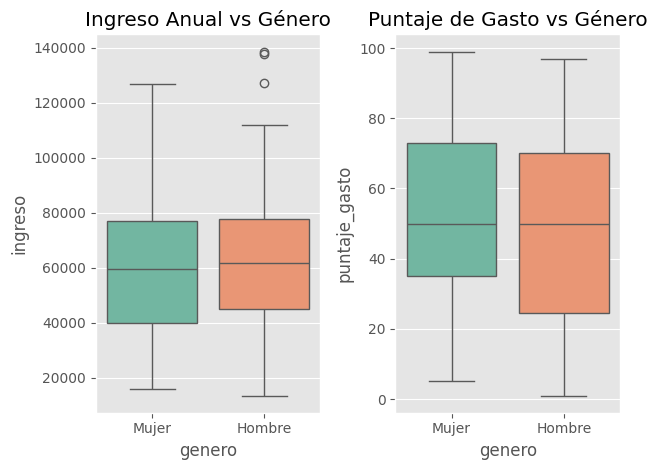

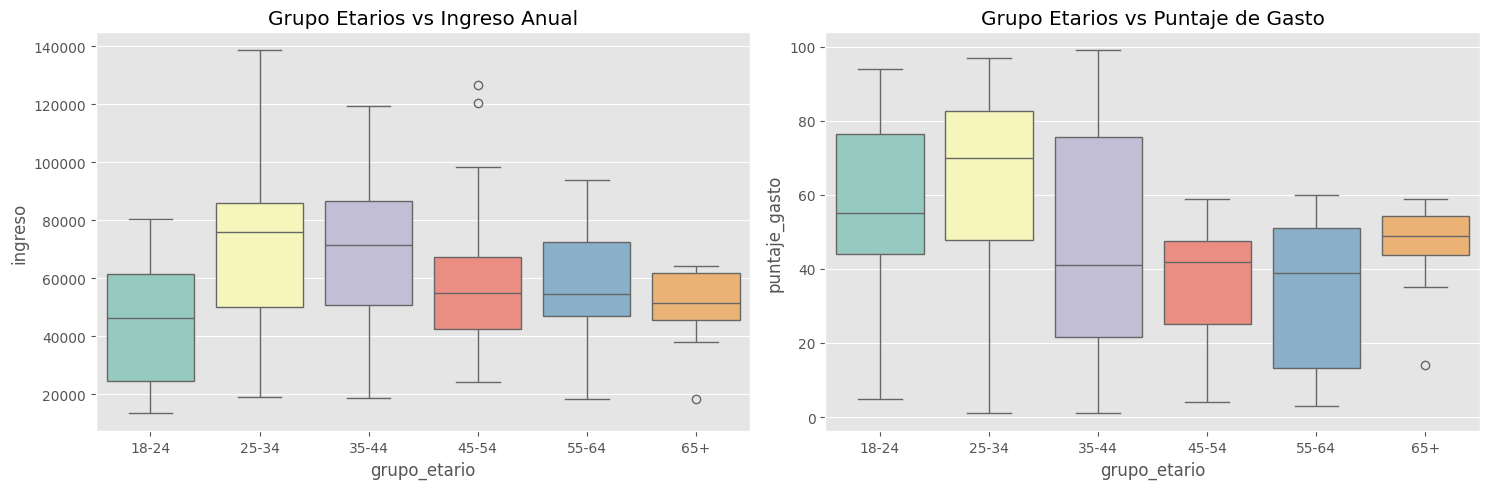

C:\Users\fevid\AppData\Local\Temp\ipykernel_10356\715103213.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


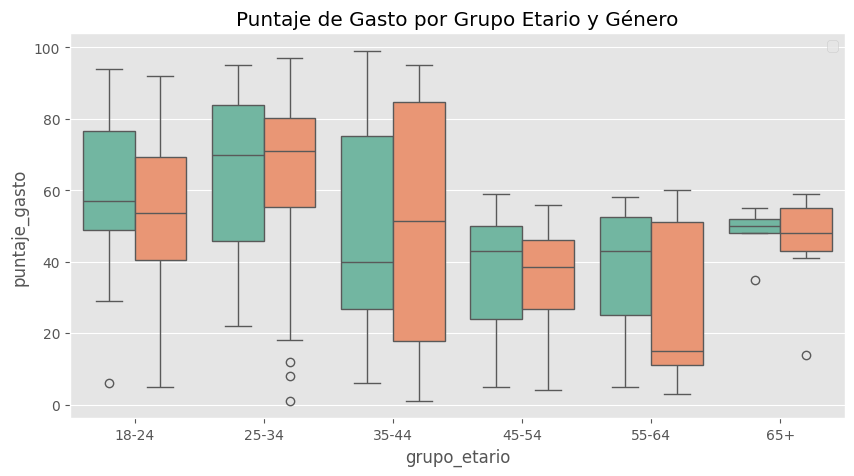

Diferencia de Ingreso por Género (T-test): p-value = 0.47
Diferencia de Gasto por Género (T-test): p-value = 0.41
Diferencia de Ingreso por Grupo Etario (ANOVA): p-value = 0.00
Diferencia de Gasto por Grupo Etario (ANOVA): p-value = 0.00


In [44]:
# Utilice este espacio para escribir el código.

#### 1. Creación de los grupos etarios para el DataFrame de los clientes

### a. Listas con los grupos por edad
corte_edad = [17, 24, 34, 44, 54, 64, 100]

grupos = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

### b. Añadimos los grupos etarios en el DataFrame tomando en cuenta la edad de los clientes registrados
df['grupo_etario'] = pd.cut(df['edad'], 
                            bins = corte_edad, 
                            labels = grupos)

### c. Separamos las variables numéricas del DataFrame en el objeto df_num
df_num = df.select_dtypes(include = 'number')

### d. Transponemos el DataFrame de las variables numéricas
resumen_tab = df_num.describe().T

### e. Añadimos una columna que contiene el número de datos vacíos (NaNs) en cada variable 
resumen_tab['NaNs'] = df_num.isna().sum()

### f. Modificamos el título de las variables en la tabla descriptiva
resumen_tab = resumen_tab.rename(columns = {
    'count': 'n',
    'mean': 'media',
    'std': 'sd',
    '50%': 'mediana'  
})

### g. Calculamos el Error Estándar (SE)
resumen_tab['se'] = resumen_tab['sd'] / np.sqrt(resumen_tab['n'])

### h. Filtramos y elegimos el orden exacto de nuestras columnas
tabla_descrip = resumen_tab[['n', 'NaNs', 'media', 'mediana', 'sd', 'se']]

tabla_descrip = tabla_descrip.drop('id_cliente', 
                                   errors = 'ignore')

### i. Mostrar la tabla descriptiva 
print("Tabla de Estadísticas Descriptivas para las variables numéricas:")
display(tabla_descrip.round(0))


#### 2. Tablas descriptivas con variables categóricas: Género y Grupos etarios

### a. Tabla de Frecuencia para el Género
tabla_genero = pd.DataFrame({
    'Frecuencia (n)': df['genero'].value_counts(),
    'Porcentaje (%)': (df['genero'].value_counts(normalize = True) * 100).round(1)
})

print()

print("=== Resumen por Género ===")
display(tabla_genero)


### b. Tabla de frecuencia para los grupos etarios
tabla_edades = pd.DataFrame({
    'Frecuencia (n)': df['grupo_etario'].value_counts(),
    'Porcentaje (%)': (df['grupo_etario'].value_counts(normalize = True) * 100).round(1)
})

print()

print("\n=== Resumen por Grupo Etario ===")
display(tabla_edades)

print()

#### 3. Gráficas descriptivas

### a. Boxplot del Género vs Ingresos
plt.subplot(1, 2, 1)
sns.boxplot(data = df, 
            x = 'genero', 
            y = 'ingreso', 
            hue = 'genero',
            palette = 'Set2', 
            legend = False)

plt.title('Ingreso Anual vs Género')

### b. Boxplot del Género vs Puntaje de Gasto
plt.subplot(1, 2, 2)
sns.boxplot(data = df, 
            x = 'genero', 
            y = 'puntaje_gasto', 
            hue = 'genero',
            palette = 'Set2', 
            legend = False)

plt.title('Puntaje de Gasto vs Género')
plt.tight_layout()
plt.show()


### c. Boxplot de los Grupos etarios vs los Ingresos
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data = df, 
            x = 'grupo_etario', 
            y = 'ingreso', 
            hue = 'grupo_etario',
            palette = 'Set3', 
            dodge=False, 
            legend = False)

plt.title('Grupo Etarios vs Ingreso Anual')


### d. Boxplot de los Grupos etarios vs el Puntaje de Gasto
plt.subplot(1, 2, 2)
sns.boxplot(data = df, 
            x = 'grupo_etario', 
            y = 'puntaje_gasto', 
            hue = 'grupo_etario',
            palette = 'Set3', 
            dodge=False,
            legend = False)

plt.title('Grupo Etarios vs Puntaje de Gasto')
plt.tight_layout()
plt.show()


### e. Interacción entre Género y Grupo Etario sobre el Gasto
plt.figure(figsize=(10, 5))
sns.boxplot(data = df, 
            x = 'grupo_etario', 
            y = 'puntaje_gasto', 
            hue = 'genero', 
            palette='Set2', 
            legend = False)

plt.title('Puntaje de Gasto por Grupo Etario y Género')
plt.legend(loc='upper right')
plt.show()

#### 2. Significancia estadística de las diferencias entre Ingresos y puntajes para los Grupos etarios

### a. Aplicamos una diferencia de medias entre los ingresos de hombres y mujeres
hombres_ing = df[df['genero'] == 'Hombre']['ingreso'].dropna()
mujeres_ing = df[df['genero'] == 'Mujer']['ingreso'].dropna()

t_ing, p_ing_gen = stats.ttest_ind(hombres_ing, mujeres_ing)

print(f"Diferencia de Ingreso por Género (T-test): p-value = {p_ing_gen:.2f}")

### b. Aplicamos una diferencia de medias entre los gastos de hombres y mujeres
hombres_gas = df[df['genero'] == 'Hombre']['puntaje_gasto'].dropna()
mujeres_gas = df[df['genero'] == 'Mujer']['puntaje_gasto'].dropna()

t_gas, p_gas_gen = stats.ttest_ind(hombres_gas, mujeres_gas)

print(f"Diferencia de Gasto por Género (T-test): p-value = {p_gas_gen:.2f}")


### c. ANOVA para los Grupos Etarios (Ingreso y Gastos)
grupos_edades = df['grupo_etario'].dropna().unique()

### d. Aplicamos una diferencia de medias (t-test) para el ingreso por grupos de edad y de puntaje de gasto en las edades
datos_ing_edad = [df[df['grupo_etario'] == edad]['ingreso'].dropna() for edad in grupos_edades]
datos_gas_edad = [df[df['grupo_etario'] == edad]['puntaje_gasto'].dropna() for edad in grupos_edades]

### e. Hacemos un ANOVA para 
f_ing, p_ing_edad = stats.f_oneway(*datos_ing_edad)
f_gas, p_gas_edad = stats.f_oneway(*datos_gas_edad)


print(f"Diferencia de Ingreso por Grupo Etario (ANOVA): p-value = {p_ing_edad:.2f}")
print(f"Diferencia de Gasto por Grupo Etario (ANOVA): p-value = {p_gas_edad:.2f}")


(Utilice este espacio para describir su procedimiento)

**Descripción del código:** iniciamos con la creación de dos listas con los cortes de los grupos etarios y las categorías de los correspondientes grupos. Posteriormente, añadimos al DataFrame la columna de *grupo_etario* que la construimos con base en las edades de los clientes registrados. Construimos tres tablas descriptivas con las variables numéricas, género y los grupos etarios. El siguiente paso consiste en hacer las gráficas de diagramas de caja que representa la relación entre las variables del DataFrame de los clientes. Por último, hacemos las pruebas de diferencia de medias (t-test) y ANOVA para determinar si hay diferencias estadísticas entre las variables estudiadas.

**Tabla descriptiva variables numéricas:**

**Tabla descriptiva del Género:**

**Tabla descriptiva de los grupos etarios:**

**Gráfica 1:**

**Gráfica 2:**

**Gráfica 3:**

**Diferencia de medias:**

**ANOVAs:**


### 3. Clustering Jerárquico

#### 3.1. Dendrogramas

Agrupe a los clientes utilizando sólo dos variables: su ingreso y el puntaje de gastos. Para ello retenga estas dos variables, estandarízelas, construya y grafique un dendograma. Para la construcción del dendrograma utilice el enlace 'ward' y la distancia euclidiana. Explique la importnacia de estandarizar los datos.

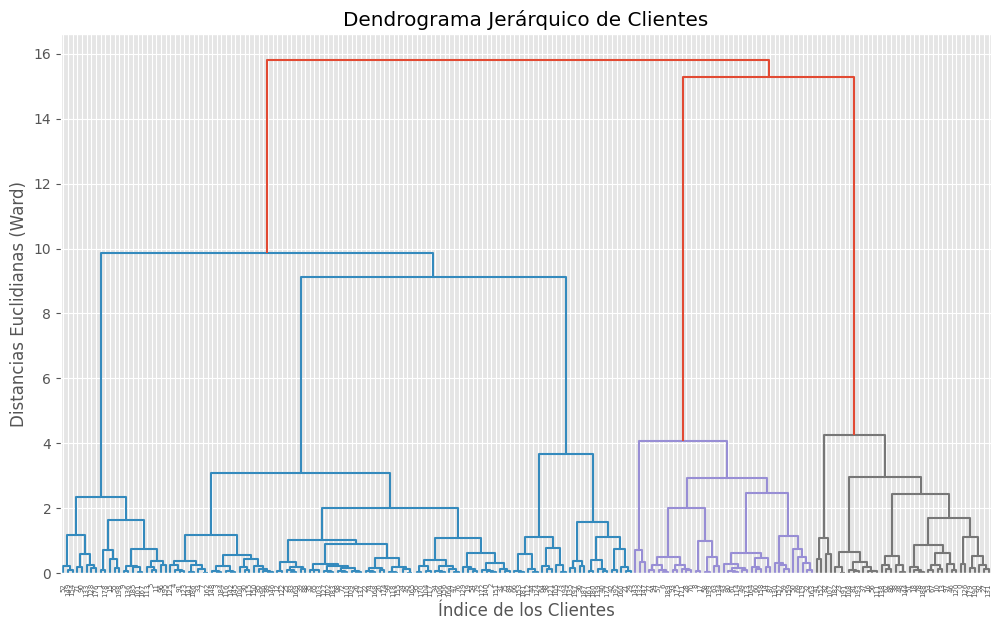

In [45]:
# Utilice este espacio para escribir el código.

#### 1. Creación de los dendogramas

### a. Seleccionamos las variables solicitadas y las guardamos en el objeto df_clustering
df_clustering = df[['ingreso', 'puntaje_gasto']]

### b. Estandarizamos los datos de las variables de ingreso y puntaje de gasto
scaler = StandardScaler()
standard_data = scaler.fit_transform(df_clustering)

### c. Calculando distancias y aplicando el método de Ward con distancia euclidiana
Z = sch.linkage(standard_data, 
                method='ward', 
                metric='euclidean')

### d. Graficamos el dendograma
plt.figure(figsize=(12, 7))
sch.dendrogram(Z);

plt.title('Dendrograma Jerárquico de Clientes')
plt.xlabel('Índice de los Clientes')
plt.ylabel('Distancias Euclidianas (Ward)')
plt.show()


(Utilice este espacio para describir su procedimiento)

**Descripción del código:** en primer lugar extraemos las variables numéricas de ingreso y puntaje del gasto, que guardamos en el objeto *df_clustering*, estandarizamos estas dos variables y con ellas calculamos el método de Ward, con la distancia euclidiana, con la función *linkage()* del paquete scipy. Finalmente, graficamos el dendograma con la función *dendogram()* y la librería *matplotlib*.

**Dendograma:** la gráfica nos muestra que lo ideal es segmentar los clientes en cinco clústeres, ya que la parte derecha de la gráfica (grupos violeta y negro) tienen la línea vertical más larga del gráfico.

#### 3.2. Número de clusters

Retenga el número de clusters que se obtengan luego de fijar la distancia en 6.

In [46]:
# Utilice este espacio para escribir el código.

#### 1. Número de clústers con una distancia fija de 6

### a. Fijamos la distancia igual a 6 y la guardamos en el objeto distancia
distancia = 6

### b. Aplicando el fcluster para obtener las etiquetas de los grupos 
cluster_tags = sch.fcluster(Z, 
                            t = distancia, 
                            criterion = 'distance')

### c. Añadiendo las etiquetas al DataFrame
df['cluster_jerarquico'] = cluster_tags

### d. Calculando el número exacto de clústeres
numero_clusters = len(np.unique(cluster_tags))

print(f"Al fijar la distancia euclidiana en {distancia}, el algoritmo determinó {numero_clusters} clusters.")

print()

### e. Calculando el número de clientes por cluster
distribucion = df['cluster_jerarquico'].value_counts().sort_index()

print('Número de clientes por clúster')
display(distribucion.to_frame(name='Cantidad de Clientes'))

Al fijar la distancia euclidiana en 6, el algoritmo determinó 5 clusters.

Número de clientes por clúster


,Cantidad de Clientes
cluster_jerarquico,
1,23
2,74
3,26
4,39
5,38


(Utilice este espacio para describir su procedimiento)

 **Descripción del código:** fijamos la distancia igual a 6, aplicamos la función de *fcluster()* para obtener las etiquetas que añadimos al DataFrame. Calculamos el número exacto de clusters y con la función *value_counts()* calculamos la tabla de frecuencia para los clúster con distancia igual a 6.

 **Tabla de clientes por cluster:** la tabla nos muetsra que los clúster dos, cuatri y cinco agrupan la mayor cantidad de clientes respectivamente.


#### 3.3. Algoritmo Jerárquico Aglomerativo

Utilizando el número de clusters encontrados en el paso anterior, aplique el algoritmo jerárquico aglomerativo, utilizando el enlace 'ward' y la distancia euclidiana. Describa los grupos encontrados, en que grupo o grupos concentraría su estrategia de marketing y por qué?

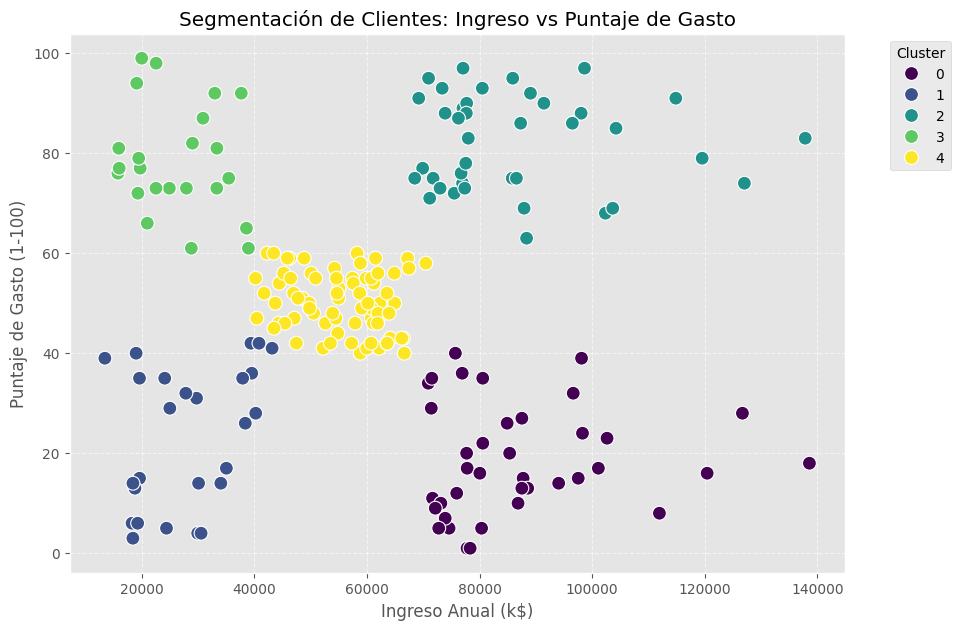

=== Perfil de los Grupos Encontrados ===


,ingreso,puntaje_gasto,edad
cluster_final,,,
0,87055.1,18.6,40.4
1,28274.7,23.3,44.1
2,86537.5,82.1,32.7
3,26230.4,78.6,25.5
4,55451.3,50.2,43.6


In [ ]:
# Utilice este espacio para escribir el código.

#### 1. Construyendo el algoritmo Jerárquico Aglomerativo

### a. Modelo con 5 clústeres
modelo_jerarquico = AgglomerativeClustering(n_clusters = 5, 
                                            linkage = 'ward', 
                                            metric = 'euclidean')

### b. Guardamos las predicciones estimadas en el DataFrame
df['cluster_final'] = modelo_jerarquico.fit_predict(standard_data)

### c. Gráfica de los clusteres
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='ingreso', y='puntaje_gasto', hue='cluster_final', palette='viridis', s=100)

plt.title('Segmentación de Clientes: Ingreso vs Puntaje de Gasto')
plt.xlabel('Ingreso Anual')
plt.ylabel('Puntaje de Gasto')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### d. Tabla con el perfil de los grupos calculados
resumen_clusters = df.groupby('cluster_final')[['ingreso', 'puntaje_gasto', 'edad']].mean().round(1)
print("=== Perfil de los Grupos Encontrados ===")
display(resumen_clusters)


(Utilice este espacio para describir su procedimiento)

**Descripción del código:**

**Gráfico de clústeres:**

**Tabla de los clúster:**

### 4. DBSCAN

Implemente DBSCAN, al igual que el punto anterior sólo dos variables: su ingreso y el puntaje de gastos. Al implementar  justifique su elección de `min_samples` y `eps`. ¿Cuántos grupos o clusters encuentra? ¿Cuáles son su características? ¿Cambiaría su estrategia de marketing respecto al punto anterior? Justifique su respuesta.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir su procedimiento)

### 5. Incorporando más dimensiones

Hasta este momento hemos utilizado solo dos variables para nuestro análisis, sin embargo, la base cuenta con otras variables más: género y edad. Usando las categorías de edad creadas anteriormente incorpore género y grupo etario a su análisis. Genere los grupos utilizando DBSCAN y la distancia de Gower, justificando su elección de `min_samples` y `eps`   ¿Incorporar estas variables, ayuda a la focalización de la estrategia de marketing?

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir su procedimiento)